# Uncertainty Features

**Chapter 9 | Section 9.4**

**Docker image**: `ml4t`

Every model in this chapter has produced an estimate. A model that also produces a
statement about how sure it is of that estimate is producing two features, and the second
one is often the more useful: a signal the model is confident about and a signal it is
guessing at should not be traded the same size, and only the second feature can tell them
apart.

**Learning objectives**

- Fit a volatility model that returns a distribution over its estimate rather than a
  single number, and extract the width of that distribution as a column.
- Refit it forward through a sample so that no posterior reads its own future, and say
  what the cost of doing so is when each fit takes minutes.
- Check that the sampler that produced the posterior actually converged, rather than
  assuming it, and know which two numbers say so.
- Turn a forecast interval into a feature, and recognize when the interval is telling you
  about the data and when it is telling you about the model.

**Book reference**

Chapter 9, Section 9.4 (Uncertainty features).

**Prerequisites**

`08_garch_volatility` for a point-estimate volatility model and for the filter-forward
construction this notebook's cost forces it to approximate. `09_har_rough_volatility` for
the Garman-Klass estimator used as the target here.

## Setup

In [1]:
"""Uncertainty features - posterior widths and forecast intervals as columns."""

import logging
import warnings
from datetime import datetime

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import pymc as pm
from IPython.display import display
from ml4t.diagnostic.evaluation.autocorrelation import analyze_autocorrelation
from ml4t.diagnostic.evaluation.stationarity import analyze_stationarity
from ml4t.diagnostic.logging import LogLevel, configure_logging
from ml4t.engineer.features.volatility import garman_klass_volatility
from statsforecast import StatsForecast
from statsforecast.models import ARIMA, AutoARIMA
from statsmodels.tools.sm_exceptions import InterpolationWarning

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, show_with_alt

# A KPSS p-value is read off a published table and saturates at its ends; the returned
# p-value already reports that, and the section below reads it.
warnings.filterwarnings(
    "ignore",
    message="The test statistic is outside of the range of p-values",
    category=InterpolationWarning,
)
configure_logging(LogLevel.WARNING)  # the diagnostic library logs each test at INFO
# The line search is a step of the optimizer, not a statement about the posterior, and it
# reports non-convergence thousands of times per fit. Both messages are named, so overflow,
# divide-by-zero and invalid-value stay visible.
warnings.filterwarnings(
    "ignore", message="The line search algorithm did not converge", category=RuntimeWarning
)
warnings.filterwarnings(
    "ignore",
    message="Rounding errors prevent the line search from converging",
    category=RuntimeWarning,
)
# PyTensor announces at import whether it found a BLAS library. That is a fact about the
# machine, it repeats on every run, and it says nothing about the model.
warnings.filterwarnings("ignore", message="PyTensor could not link to a BLAS", category=UserWarning)

In [2]:
START_DATE = "2015-01-01"
END_DATE = "2024-12-31"
N_DRAWS = 1000
N_TUNE = 2000
N_CHAINS = 2
REFIT_INTERVAL = 63  # sessions between refits: about one quarter
TRAIN_DAYS = 252  # sessions each fit reads: about one year
ARIMA_WINDOW = 252
SEED = 42

In [3]:
set_global_seeds(SEED)

## The data

SPY daily bars, with returns in percent and a Garman-Klass volatility as the target for
the forecasting half. `09_har_rough_volatility` is where that estimator is compared
against the alternatives; it is used here because it reads the whole daily bar rather
than only the close.

In [4]:
SESSIONS_PER_YEAR = 252
VOLATILITY_WINDOW = 21

spy = (
    load_etfs(symbols=["SPY"])
    .select(["timestamp", "open", "high", "low", "close"])
    .filter(pl.col("timestamp") >= datetime.strptime(START_DATE, "%Y-%m-%d").date())
    .filter(pl.col("timestamp") <= datetime.strptime(END_DATE, "%Y-%m-%d").date())
    .sort("timestamp")
    .with_columns(
        returns=pl.col("close").pct_change() * 100,
        volatility=garman_klass_volatility(
            "open", "high", "low", "close", period=VOLATILITY_WINDOW
        ),
    )
    .drop_nulls()
)

frame = spy.to_pandas().set_index("timestamp")
returns = frame["returns"]
realized_volatility = frame["volatility"]

print(f"SPY: {len(frame):,} sessions, {frame.index.min().date()} to {frame.index.max().date()}")
print(f"Daily return: mean {returns.mean():.4f} percent, standard deviation {returns.std():.4f}")
print(
    f"Garman-Klass volatility over {VOLATILITY_WINDOW} sessions: mean {realized_volatility.mean():.4f}"
)

SPY: 2,496 sessions, 2015-02-02 to 2024-12-31
Daily return: mean 0.0564 percent, standard deviation 1.1101
Garman-Klass volatility over 21 sessions: mean 0.1189


## What an uncertainty feature is

Take any statistic a model produces. Estimated by maximum likelihood it is one number;
estimated by sampling from a posterior it is a distribution, and the width of that
distribution is a second quantity that varies over time for reasons the point estimate
does not. A Sharpe ratio computed from a hundred sessions and one computed from a
thousand can be the same number and mean entirely different things.

The example below is the smallest version of that: the Sharpe ratio of this sample as a
single number, with nothing attached saying how far it could be from the truth. Chapter
17 develops the Bayesian version in full. This notebook applies the same idea to
volatility, where the payoff is larger because the quantity being estimated moves.

In [5]:
sharpe = returns.mean() / returns.std() * np.sqrt(SESSIONS_PER_YEAR)
print(f"Sharpe ratio over the whole sample: {sharpe:.3f}")
print(f"Sessions it was computed from: {len(returns):,}")

Sharpe ratio over the whole sample: 0.806
Sessions it was computed from: 2,496


## A volatility model that returns a distribution

The **stochastic volatility** model treats log-volatility as an unobserved series that
follows its own autoregression, and the returns as draws whose scale is that hidden
series:

$$\log \sigma_t = \mu_h + \phi\,(\log \sigma_{t-1} - \mu_h) + \sigma_\eta\,\eta_t$$

It differs from GARCH in what it treats as unknown. GARCH says the variance is a
deterministic function of past returns, so given the parameters there is one variance
path and no uncertainty about it. Stochastic volatility says the variance has its own
noise, so even with the parameters known the path is uncertain, and fitting it produces
a distribution at every session rather than a number.

Three parameters carry the model. $\phi$ is how persistent volatility is, $\sigma_\eta$
is how much the volatility process itself moves, and the observation distribution is
Student-t rather than normal, whose degrees of freedom $\nu$ is estimated: a small $\nu$
says the returns have tails a normal cannot produce, and a large one says a normal would
have done.

In [6]:
def fit_stochastic_volatility(observations: np.ndarray):
    """Sample the posterior of an autoregressive stochastic volatility model."""
    with pm.Model():
        mu_h = pm.Normal("mu_h", mu=0, sigma=5)
        phi = pm.Uniform("phi", lower=0, upper=1)
        sigma_eta = pm.Exponential("sigma_eta", lam=2)
        nu = pm.Deterministic("nu", pm.Gamma("nu_minus_two", alpha=2, beta=0.1) + 2)

        centered = pm.AR(
            "centered",
            rho=[phi],
            sigma=sigma_eta,
            init_dist=pm.Normal.dist(0, 1),
            shape=len(observations),
        )
        volatility = pm.Deterministic("volatility", pm.math.exp((centered + mu_h) / 2))
        pm.StudentT("observed_returns", nu=nu, mu=0, sigma=volatility, observed=observations)

        return pm.sample(
            N_DRAWS,
            tune=N_TUNE,
            chains=N_CHAINS,
            cores=1,
            progressbar=False,
            random_seed=SEED,
            target_accept=0.99,
        )

## Refitting forward, and what it costs

Each fit takes minutes, which decides the shape of everything below. The model is refit
quarterly on the preceding year of returns, and from each fit two kinds of feature come
out.

The **parameters** are one number per fit by construction: how persistent volatility is
and how much the volatility process moves are properties of a window, not of a session,
so a column holding them is genuinely constant between refits and nothing is lost.

The **level** is not. What is extracted here is the posterior at the last session of the
training window, which is a filtered quantity conditioned only on data up to that point
and therefore causal. Carried forward for a quarter it stops being a volatility estimate:
by the end of the quarter it describes a session three months old. Use it as written for
the parameter columns and read `08_garch_volatility` for the level, where a cheap
recursion filters forward between refits at no cost. Making the same thing work here
needs a particle filter, which is the standard answer and is outside this notebook.

In [7]:
forecast_start = len(returns) - TRAIN_DAYS
refit_points = list(range(forecast_start, len(returns), REFIT_INTERVAL))

print(f"Refits: {len(refit_points)}, one every {REFIT_INTERVAL} sessions")
print(f"Each reads the preceding {TRAIN_DAYS} sessions")
print(f"Sessions covered: {len(returns) - forecast_start}")

Refits: 4, one every 63 sessions
Each reads the preceding 252 sessions
Sessions covered: 252


In [8]:
posterior_rows = []
traces = []

for index, cut in enumerate(refit_points, start=1):
    training = returns.iloc[max(0, cut - TRAIN_DAYS) : cut].to_numpy()
    trace = fit_stochastic_volatility(training)
    traces.append(trace)

    final_volatility = trace.posterior["volatility"].values[:, :, -1].flatten()
    features = {
        "posterior_mean": float(final_volatility.mean()),
        "posterior_std": float(final_volatility.std()),
        "interval_width": float(np.diff(np.percentile(final_volatility, [2.5, 97.5]))[0]),
        "vol_of_vol": float(trace.posterior["sigma_eta"].values.mean()),
        "persistence": float(trace.posterior["phi"].values.mean()),
        "tail_parameter": float(trace.posterior["nu"].values.mean()),
        "divergences": int(trace.sample_stats["diverging"].values.sum()),
    }
    for stamp in returns.index[cut : min(cut + REFIT_INTERVAL, len(returns))]:
        posterior_rows.append({"timestamp": stamp, "refit": index, **features})

posteriors = pd.DataFrame(posterior_rows).set_index("timestamp")
per_refit = posteriors.groupby("refit").first()
display(per_refit)

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [mu_h, phi, sigma_eta, nu_minus_two, centered]


Sampling 2 chains for 2_000 tune and 1_000 draw iterations (4_000 + 2_000 draws total) took 60 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Sampling 2 chains for 2_000 tune and 1_000 draw iterations (4_000 + 2_000 draws total) took 50 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,posterior_mean,posterior_std,interval_width,vol_of_vol,persistence,tail_parameter,divergences
refit,,,,,,,
1,0.737077,0.144451,0.575925,0.213900,0.606046,29.741403,0
2,0.687401,0.091145,0.379143,0.197516,0.363202,26.470616,0
3,0.650636,0.114821,0.463394,0.271485,0.430777,27.040606,0
4,0.695019,0.181799,0.718288,0.329555,0.756428,25.244887,0


## Did the sampler converge

A posterior is only worth reading if the sampler explored it, and three numbers say
whether it did. **Divergences** are steps the sampler could not take and are counted
above; any at all are a warning. $\hat{R}$ compares the variance between chains against
the variance within them and should be at or very near one. The **effective sample size**
is how many independent draws the correlated ones are worth, and a few hundred is the
usual floor for a stable posterior mean.

This model is a hard one for the sampler, and the reason is structural rather than a
matter of tuning: the persistence, the volatility of volatility and the hidden path are
not separately identified by the data, so the posterior has a narrow curved region the
sampler has to follow. Expect the two parameters to have lower effective sample sizes
than the ones the returns pin down directly.

In [9]:
R_HAT_CEILING = 1.01
EFFECTIVE_SAMPLE_FLOOR = 200
DIAGNOSTIC_PARAMETERS = ["phi", "sigma_eta", "mu_h", "nu"]

diagnostics = (
    pd.concat(
        az.summary(trace, var_names=DIAGNOSTIC_PARAMETERS)[
            ["mean", "sd", "r_hat", "ess_bulk", "mcse_mean"]
        ]
        .rename_axis("parameter")
        .assign(refit=index)
        for index, trace in enumerate(traces, start=1)
    )
    .set_index("refit", append=True)
    .reorder_levels(["refit", "parameter"])
    .sort_index()
)
display(diagnostics)

print(f"Parameter fits in total: {len(diagnostics)}")
print(f"Above the r_hat ceiling: {(diagnostics['r_hat'] > R_HAT_CEILING).sum()}")
print(
    f"Below the effective sample floor: {(diagnostics['ess_bulk'] < EFFECTIVE_SAMPLE_FLOOR).sum()}"
)
print(f"Divergences in the worst refit: {posteriors['divergences'].max()}")

mean      sd  r_hat  ess_bulk  mcse_mean
refit parameter                                            
1     mu_h       -0.523   0.195   1.01     356.0      0.012
      nu         29.741  15.292   1.00    1594.0      0.369
      phi         0.606   0.326   1.17      10.0      0.112
      sigma_eta   0.214   0.113   1.36       5.0      0.054
2     mu_h       -0.748   0.112   1.01     586.0      0.005
      nu         26.471  14.064   1.01     872.0      0.468
      phi         0.363   0.248   1.12      12.0      0.073
      sigma_eta   0.198   0.125   1.41       4.0      0.054
3     mu_h       -0.833   0.122   1.00     825.0      0.004
      nu         27.041  14.425   1.00    1412.0      0.342
      phi         0.431   0.250   1.05      51.0      0.037
      sigma_eta   0.271   0.109   1.04      23.0      0.023
4     mu_h       -0.712   0.206   1.00     400.0      0.011
      nu         25.245  14.195   1.00    2504.0      0.281
      phi         0.756   0.224   1.04      21.0      0.052
      sigma_eta   0.330   0.155   1.10      17.0      0.037

Parameter fits in total: 16
Above the r_hat ceiling: 8
Below the effective sample floor: 8
Divergences in the worst refit: 0


## Whether the sampler noise is large enough to matter

Two of these parameters are features, so a failed diagnostic is not an academic point
about the fit; it decides whether the column carries anything. Two quantities bound the
question. The **Monte Carlo standard error** is how far one fit's posterior mean could be
from the mean the sampler was estimating, purely because it took finitely many draws; it is
reported per refit above because it differs between them. The **spread across refits** is
how much the feature moves from quarter to quarter, which is the variation a model would
read.

Putting the largest error next to that spread says whether sampling error is large enough
to matter. It does not divide the spread into signal and noise: each fit's error is a
separate quantity, and a fit whose diagnostics failed makes its own error estimate
unreliable.

In [10]:
FEATURE_PARAMETERS = {"phi": "persistence", "sigma_eta": "vol_of_vol"}


def sampling_error_row(name: str, column: str) -> dict:
    """The Monte Carlo error of the noisiest fit against the spread across all of them."""
    errors = diagnostics.xs(name, level="parameter")["mcse_mean"]
    spread = per_refit[column].std()
    return {
        "parameter": column,
        "smallest Monte Carlo error across refits": errors.min(),
        "largest Monte Carlo error across refits": errors.max(),
        "spread across refits": spread,
        "ratio of the largest error to the spread": errors.max() / spread,
    }


display(
    pd.DataFrame([sampling_error_row(name, column) for name, column in FEATURE_PARAMETERS.items()])
)

,parameter,smallest Monte Carlo error across refits,largest Monte Carlo error across refits,spread across refits,ratio of the largest error to the spread
0,persistence,0.037,0.112,0.177376,0.631426
1,vol_of_vol,0.023,0.054,0.060027,0.899602


Read the last column before using either parameter as a feature. A ratio that is a
meaningful fraction of one says the sampler alone could move the column by an amount
comparable to what it moves between quarters, which is enough to make the
quarter-to-quarter path unreliable at that resolution. It does not say what share of the
path is sampling error; establishing that means rerunning the fits with more draws and
watching whether the spread stays where it was. The draws needed scale with the square of
how much further the error has to fall.

This is a property of the model rather than of the data, and it is worth knowing which
models have it. A likelihood with a narrow curved region takes many draws to explore
whichever way it is sampled, and the standard responses are a non-centered
parameterization of the latent path, far longer chains, or a sampler built for
state-space models rather than a general-purpose one.

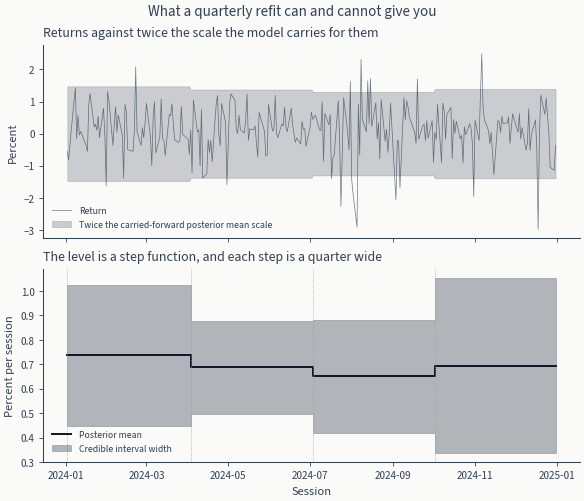

In [11]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], sharex=True)

covered = posteriors.index
ax = axes[0]
ax.plot(
    covered, returns.loc[covered], linewidth=0.5, alpha=0.7, color=COLORS["neutral"], label="Return"
)
ax.fill_between(
    covered,
    -2 * posteriors["posterior_mean"],
    2 * posteriors["posterior_mean"],
    alpha=0.2,
    color=COLORS["blue"],
    label="Twice the carried-forward posterior mean scale",
)
ax.set_ylabel("Percent")
ax.set_title("Returns against twice the scale the model carries for them")
ax.legend(fontsize=7)

ax = axes[1]
ax.plot(
    covered,
    posteriors["posterior_mean"],
    linewidth=1.4,
    drawstyle="steps-post",
    color=COLORS["blue"],
    label="Posterior mean",
)
ax.fill_between(
    covered,
    posteriors["posterior_mean"] - posteriors["interval_width"] / 2,
    posteriors["posterior_mean"] + posteriors["interval_width"] / 2,
    step="post",
    alpha=0.3,
    color=COLORS["blue"],
    label="Credible interval width",
)
for cut in refit_points:
    ax.axvline(returns.index[cut], color=COLORS["recede"], linestyle=":", linewidth=0.6)
ax.set_ylabel("Percent per session")
ax.set_xlabel("Session")
ax.set_title("The level is a step function, and each step is a quarter wide")
ax.legend(fontsize=7)

fig.suptitle("What a quarterly refit can and cannot give you")
show_with_alt(
    fig,
    "Two stacked panels over the last year of the sample. The top draws daily returns "
    "against a shaded band at twice the posterior mean of the scale parameter, which steps "
    "to a new level at each refit and does not follow the returns within a quarter. The "
    "bottom draws the "
    "posterior mean as a step function with its credible interval shaded around it and "
    "dotted vertical lines at the refit dates; the steps differ in level and the interval "
    "differs in width between them.",
)

The bottom panel is the argument of the section above, drawn. The level steps once a
quarter and holds, so within a quarter it says nothing about which sessions were volatile.
What does carry information at that cadence is the width of the interval relative to the
level, and how the parameters move between fits.

In [12]:
posteriors["relative_width"] = posteriors["interval_width"] / posteriors["posterior_mean"]
display(
    per_refit.assign(relative_width=per_refit["interval_width"] / per_refit["posterior_mean"])[
        ["posterior_mean", "interval_width", "relative_width", "persistence", "vol_of_vol"]
    ]
)

,posterior_mean,interval_width,relative_width,persistence,vol_of_vol
refit,,,,,
1,0.737077,0.575925,0.781364,0.606046,0.213900
2,0.687401,0.379143,0.551560,0.363202,0.197516
3,0.650636,0.463394,0.712217,0.430777,0.271485
4,0.695019,0.718288,1.033480,0.756428,0.329555


## The parameter posteriors

The four histograms are the model's statement about how well each parameter is pinned
down. A narrow posterior is a parameter the data determined; a wide one spanning most of
its prior is a parameter the data had little to say about, and reading its mean as an
estimate would be reading the prior back.

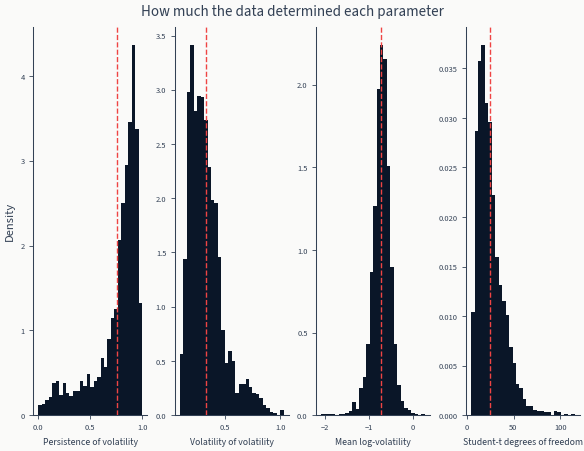

In [13]:
POSTERIOR_LABELS = {
    "phi": "Persistence of volatility",
    "sigma_eta": "Volatility of volatility",
    "mu_h": "Mean log-volatility",
    "nu": "Student-t degrees of freedom",
}

fig, axes = plt.subplots(1, len(POSTERIOR_LABELS), figsize=FIGSIZE["dashboard_2x3"])

for ax, (name, label) in zip(axes, POSTERIOR_LABELS.items()):
    samples = traces[-1].posterior[name].values.flatten()
    ax.hist(samples, bins=30, density=True, color=COLORS["blue"])
    ax.axvline(samples.mean(), color=COLORS["negative"], linestyle="--", linewidth=1)
    ax.set_xlabel(label, fontsize=7)
    ax.tick_params(labelsize=6)
axes[0].set_ylabel("Density")

fig.suptitle("How much the data determined each parameter")
show_with_alt(
    fig,
    "Four histograms of the posterior draws from the most recent fit, one per parameter, "
    "each with a dashed line at its mean. The persistence and the mean log-volatility are "
    "concentrated; the volatility of volatility is narrower still; the Student-t degrees of "
    "freedom is broad and skewed to the right, spanning a wide range of values.",
)

The degrees-of-freedom posterior is the one to read carefully. It is bounded below by two
and unbounded above, and a large value means the Student-t has become a normal. A broad
right tail therefore says the data does not rule out a normal rather than that the tails
are thick, and the parameter's mean is a poor summary of a distribution shaped like that.

## Forecast intervals as a feature

The second source of uncertainty in this notebook is cheaper and different in kind. An
ARIMA forecast comes with a prediction interval, and that interval widens when the model
fits the recent past badly. It is available at every session at negligible cost, which is
the opposite trade from the sampler above.

The model is fitted to the **logarithm** of volatility, for two reasons. A forecast on
the log scale exponentiates to something positive, which a volatility has to be. And the
residuals of a log-volatility model are much closer to normal than those of a
volatility model, which is what the interval's construction assumes.

The back-transform is exact rather than approximate, and it is worth being precise about
what it gives. If the forecast on the log scale is normal with mean $\mu$ and standard
deviation $s$, then on the original scale $e^{\mu}$ is the **median** and
$e^{\mu + s^2/2}$ is the mean, and exponentiating the endpoints of the interval on the
log scale gives an interval on the original scale with exactly the stated coverage. The interval is asymmetric around the median, wider
above than below, which is right for a quantity with a floor at zero and no ceiling.

In [14]:
log_volatility = np.log(realized_volatility.clip(lower=1e-8))

stationarity = analyze_stationarity(log_volatility.dropna().to_numpy())
autocorrelation = analyze_autocorrelation(log_volatility.dropna().to_numpy())

display(stationarity.summary_df)
print(f"Consensus: {stationarity.consensus}, agreement {stationarity.agreement_score:.2f}")
print(f"Order suggested from the correlogram: {autocorrelation.suggested_arima_order}")

,test_name,test_statistic,p_value,is_stationary,conclusion,alpha
0,ADF,-3.917868,0.001907,True,Stationary,0.05
1,KPSS,0.792039,0.010000,False,Non-stationary,0.05
2,PP,-4.587332,0.000136,True,Stationary,0.05


Consensus: likely_stationary, agreement 0.67
Order suggested from the correlogram: (5, 0, 33)


The three tests do not agree, which is the useful outcome here rather than an obstacle.
The differencing order is exactly what they disagree about, so rather than picking one
test's answer the order is chosen by an information criterion over the first training
window and then held fixed, and the selected order is printed below.

In [15]:
NIXTLA_FREQUENCY = "B"
CONFIDENCE = 95
Z_SCORE = 1.959964

series = pd.DataFrame(
    {
        "unique_id": "SPY",
        "ds": log_volatility.dropna().index,
        "y": log_volatility.dropna().to_numpy(),
    }
)

selector = StatsForecast(models=[AutoARIMA(season_length=1)], freq=NIXTLA_FREQUENCY, n_jobs=1)
selector.fit(series.head(ARIMA_WINDOW))
p, q, _seasonal_p, _seasonal_q, _season, d, _seasonal_d = selector.fitted_[0, 0].model_["arma"]
print(f"Order selected on the first {ARIMA_WINDOW} sessions: ARIMA({p}, {d}, {q})")

Order selected on the first 252 sessions: ARIMA(1, 1, 1)


In [16]:
rolling = StatsForecast(
    models=[ARIMA(order=(p, d, q), season_length=1)], freq=NIXTLA_FREQUENCY, n_jobs=1
).cross_validation(
    df=series, h=1, step_size=1, n_windows=len(series) - ARIMA_WINDOW, level=[CONFIDENCE]
)

forecasts = pd.DataFrame(
    {
        "timestamp": rolling["ds"].to_numpy(),
        # On the log scale the interval is symmetric, so half its width over the z-score is
        # the forecast standard deviation. That quantity does not survive the back-transform.
        "log_forecast_std": (
            rolling[f"ARIMA-hi-{CONFIDENCE}"].to_numpy()
            - rolling[f"ARIMA-lo-{CONFIDENCE}"].to_numpy()
        )
        / (2 * Z_SCORE),
        "median_forecast": np.exp(rolling["ARIMA"].to_numpy()),
        "lower": np.exp(rolling[f"ARIMA-lo-{CONFIDENCE}"].to_numpy()),
        "upper": np.exp(rolling[f"ARIMA-hi-{CONFIDENCE}"].to_numpy()),
        "actual": np.exp(rolling["y"].to_numpy()),
    }
).set_index("timestamp")

forecasts["interval_ratio"] = forecasts["upper"] / forecasts["lower"]
forecasts["interval_width"] = forecasts["upper"] - forecasts["lower"]

print(f"One-step forecasts: {len(forecasts):,}")
print(
    "Coverage of the stated interval: "
    f"{((forecasts['actual'] >= forecasts['lower']) & (forecasts['actual'] <= forecasts['upper'])).mean():.1%}"
    f", against the {CONFIDENCE}% claimed"
)

One-step forecasts: 2,244
Coverage of the stated interval: 96.9%, against the 95% claimed


The coverage line is the check the interval exists to pass, and it is the one number in
this section that says whether the uncertainty estimate is any good. An interval that
contains the outcome far more often than it claims is too wide and one that contains it
less often is too narrow; either way the width is not the quantity it says it is.

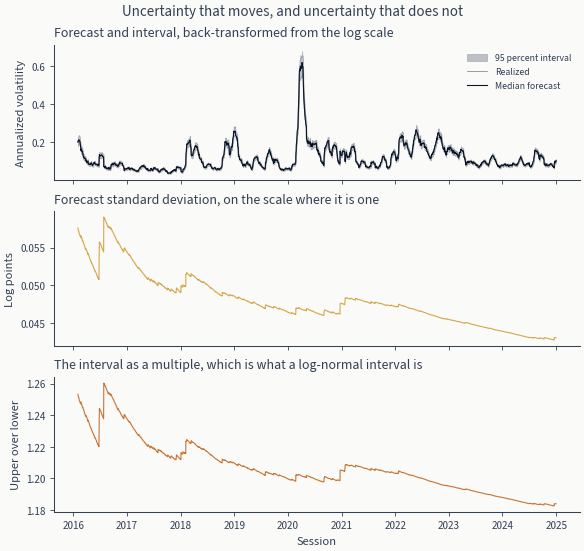

In [17]:
fig, axes = plt.subplots(3, 1, figsize=FIGSIZE["grid_3x2"], sharex=True)

ax = axes[0]
ax.fill_between(
    forecasts.index,
    forecasts["lower"],
    forecasts["upper"],
    alpha=0.25,
    color=COLORS["blue"],
    label=f"{CONFIDENCE} percent interval",
)
ax.plot(
    forecasts.index,
    forecasts["actual"],
    linewidth=0.5,
    alpha=0.7,
    color=COLORS["neutral"],
    label="Realized",
)
ax.plot(
    forecasts.index,
    forecasts["median_forecast"],
    linewidth=0.8,
    color=COLORS["blue"],
    label="Median forecast",
)
ax.set_ylabel("Annualized volatility")
ax.set_title("Forecast and interval, back-transformed from the log scale")
ax.legend(fontsize=7)

ax = axes[1]
ax.plot(forecasts.index, forecasts["log_forecast_std"], linewidth=0.8, color=COLORS["amber"])
ax.set_ylabel("Log points")
ax.set_title("Forecast standard deviation, on the scale where it is one")

ax = axes[2]
ax.plot(forecasts.index, forecasts["interval_ratio"], linewidth=0.8, color=COLORS["copper"])
ax.set_ylabel("Upper over lower")
ax.set_xlabel("Session")
ax.set_title("The interval as a multiple, which is what a log-normal interval is")

fig.suptitle("Uncertainty that moves, and uncertainty that does not")
show_with_alt(
    fig,
    "Three stacked panels sharing a time axis. The top draws the realized volatility and "
    "the median forecast inside a shaded interval that widens where volatility is high. "
    "The middle draws the forecast standard deviation on the log scale, which drifts down "
    "across the sample with a small step up at each refit rather than rises "
    "and falls over the sample. The bottom draws the ratio of the interval's upper end to "
    "its lower end, which stays within a narrow band throughout.",
)

In [18]:
display(
    forecasts[["log_forecast_std", "interval_width", "interval_ratio"]]
    .describe()
    .loc[["mean", "std", "min", "max"]]
    .round(4)
)

,log_forecast_std,interval_width,interval_ratio
mean,0.0480,0.0223,1.2070
std,0.0035,0.0131,0.0165
min,0.0428,0.0073,1.1826
max,0.0590,0.1138,1.2604


The three columns are not three features. On a log-normal interval the ratio of the
endpoints is the exponential of twice the z-score times the forecast standard deviation,
a function of that standard deviation and nothing else, so it carries exactly the
information the middle panel does and adds none.
The width in the original units is that same quantity multiplied by the level, so it is
mostly a volatility feature wearing an uncertainty label.

The describe table says how little room the ratio has: its spread across the whole sample
is a small fraction of its mean, because the forecast standard deviation of a fixed-order
model barely moves. **The uncertainty of this model is nearly constant.** Its interval
widens in volatile periods because the level widens, not because the model becomes less
sure, and a feature built from the width would be a volatility feature.

That is the useful negative result of this half of the notebook, and it separates the two
sources cleanly. The sampler's posterior width above changes because the data changes what
is knowable; a fixed-order ARIMA's interval width changes almost entirely with the level
it is centered on.

## The features this notebook produces

| Column | What it is | Cadence |
|---|---|---|
| `persistence`, `vol_of_vol` | posterior means of the two volatility-process parameters | one value per refit, and only where the Monte Carlo error is small beside their spread |
| `posterior_std`, `interval_width` | how wide the posterior over the filtered volatility is | one value per refit |
| `relative_width` | that width over the level, so it is comparable across refits | one value per refit |
| `log_forecast_std` | the forecast standard deviation on the log scale | every session |
| `median_forecast` | the back-transformed point forecast | every session |

`interval_ratio` and the original-scale `interval_width` are deliberately absent. The
first is a function of `log_forecast_std` alone and the second is that function times the
level, so a model given either alongside the columns above is given nothing new.

The posterior columns are causal: each is the posterior at the last session of a training
window that ended before the sessions it is stamped on. The level column is causal in the
same sense and stale for the reason the section above gives.

## Key takeaways

1. **A posterior width is a second feature, free with the first.** A model fitted by
   sampling produces a distribution at every session, and how wide it is says something
   the point estimate does not.
2. **Cost decides cadence, and cadence decides which features survive it.** A model that
   takes minutes to fit is refitted quarterly, which is fine for parameters that describe
   a window and useless for a level that describes a session.
3. **Check that the sampler converged, and then check whether it matters.** Divergences,
   the between-chain to within-chain variance ratio, and the effective sample size say
   whether the posterior was explored. What decides whether a parameter is usable as a
   feature is the next comparison: its Monte Carlo standard error against how much it
   moves between refits. This model's geometry makes both numbers bad for exactly the two
   parameters that would otherwise be the features.
4. **On a log scale the forecast standard deviation is a standard deviation; after the
   back-transform nothing is.** Keep the uncertainty on the scale it was estimated on and
   exponentiate only the endpoints, which is exact.
5. **Check whether the uncertainty feature moves.** A fixed-order model's interval width
   tracks the level it is centered on, which makes it a volatility feature with a
   misleading name; the coverage check and the spread of the ratio are what reveal that.

**Known limitations.** Four refits over one year is too few to say anything about how the
posterior width behaves across regimes. The sampler's effective sample sizes for the
persistence and the volatility of volatility are low enough that their posterior means
carry real Monte Carlo error, which is stated rather than corrected. The ARIMA order is
selected once on the first window and held for the whole sample. And the coverage check
is over one symbol with overlapping windows, so it establishes the level of coverage and
not its standard error.

**Previous**: `09_har_rough_volatility` for the volatility target used here.
**Next**: `11_hmm_regimes`, which infers a hidden state rather than a hidden level.